# **🛩️ ATAS**

The ATAS (Airial Threat Assesment System) is an end-to-end machine learning engineering project that combines

- computer vision,
- structured machine learning,
- tactical scenario generation,
- and interactive visualization into a single pipeline.

**The project is divided into three major components:**

- Aircraft Classification Model
- ETA Regressor Model
- Hit Classification Model

---

**In this notebook**

# **⌚ ETA Regression Model**

This notebook focuses on building the ETA Regression Model using `scikit-learn` and `ensemble methods` to predict the minimum evasion time across `1,000,000` synthetic engagement scenarios.

## **1. Problem Definition**

Physics can tell you when a missile arrives that is simple geometry.

What it cannot tell you is **how much time the pilot actually needs to 
successfully evade it.**

Given the engagement conditions including aircraft states, missile 
specifications, and geometry, predict the **minimum time window** the pilot 
needs to initiate a successful evasion through maneuvering or deploying 
countermeasures, before the missile reaches a point where evasion becomes 
extremely difficult.

This minimum window depends on non-linear interactions between maneuverability, 
missile phase, enemy generation, and countermeasure state making it a genuine 
ML problem, not a physics calculation.

---

## **2. Data**

The data used here is synthetic, generated using real physics equations since 
real labeled engagement data does not exist publicly. This is standard practice; 
companies like Tesla and Waymo also train models on synthetic data.

**How the data was made:**
- Generated by `physics_generator.py` using real aircraft specs from `aircraft_metadata.csv`
- Stored as `synthetic_engagements.csv`

**Keys notes on Data**
- The data contains 16 columns, 1,000,000 rows
- **14 columns are input features:**
  
| Feature | Description |
|---|---|
| `launch_distance` | Distance from which the missile was fired (metres) |
| `remaining_distance` | Current distance of missile from your aircraft |
| `closure_rate` | Combined closing speed of missile + your aircraft (m/s) |
| `azimuth` | Horizontal angle of incoming threat (0°–360°) |
| `elevation` | Vertical angle of incoming threat (-90°–+90°) |
| `missile_phase` | 0 = boost, 1 = mid-course, 2 = terminal |
| `your_speed` | Your current airspeed (m/s) |
| `your_altitude` | Your current altitude (metres) |
| `your_maneuverability` | 0 = low, 1 = medium, 2 = high |
| `enemy_altitude` | Enemy aircraft altitude (metres) |
| `missile_speed` | Speed of incoming missile (m/s) |
| `missile_range` | Max effective range of missile (metres) |
| `enemy_generation` | Aircraft generation (3.5, 4, 4.5, 5) |
| `countermeasure_deployed` | 0 = not deployed, 1 = deployed |
  
- **2 columns are target labels:**
  
| Label | Description |
|---|---|
| `evasion_time` | Minimum time available to evade the missile (seconds) - **target for this model** |
| `hit` | Whether the missile hits after evasion (0 = miss, 1 = hit) - dropped here |

--- 

## **3. Evaluation**

The primary evaluation metric for this model is **MAE** (Mean Absolute Error) -
it tells us how many seconds off the prediction is on average, which is directly 
meaningful in a tactical context.

**All three metrics will be tracked:**

| Metric | Goal |
|---|---|
| MAE | As low as possible (seconds) |
| RMSE | As low as possible - penalises large errors harder than MAE |
| R² | > 0.90 |

---

> Note: The goal for all three metrics is to minimise error. A well-performing model should predict evasion time within a small margin of seconds large errors are tactically dangerous.

---

## **4. Features**

Some information about the data:

* We are dealing with structured tabular data so we will be using ensemble methods (Random Forest, XGBoost).
* The dataset contains `1,000,000` synthetic engagement scenarios across `101` aircraft types.
* All 14 input features are numerical - no text, no images, no missing values.
* Features span four groups:
   * **Engagement geometry:** `launch_distance`, `remaining_distance`, `closure_rate`, `azimuth`, `elevation`, `missile_phase`
   * **Your aircraft state:** `your_speed`, `your_altitude`, `your_maneuverability`
   * **Enemy aircraft state:** `enemy_altitude`
   * **Threat specs:** `missile_speed`, `missile_range`, `enemy_generation`, `countermeasure_deployed`
* The target variable is `evasion_time` (float, seconds) — the `hit` column is dropped.
* Data was generated deterministically from physics rules no noise, no class imbalance issues.
  
* Features like `azimuth`, `elevation`, and `countermeasure_deployed` introduce non-linear interactions that make this a genuine ML problem rather than a simple physics calculation.

---

## **5. Preparing the Tools**

We will be using the following libraries for this project:

* **NumPy** → numerical operations
* **Pandas** → loading and manipulating the synthetic engagement dataset
* **Matplotlib** → visualizing feature distributions and model performance
* **Scikit-learn** → model training, evaluation metrics, and train/test split
* **XGBoost** → gradient boosted trees (primary candidate)
* **Joblib** → saving and loading trained models

In [1]:
# Importing the Librabries
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import xgboost
import joblib

%matplotlib inline

In [2]:
# Use for naming the files
import datetime, pytz
ist = pytz.timezone("Asia/Kolkata")
datetime.datetime.now(ist).strftime('%Y-%m-%d_%H-%M-%S')

'2026-05-27_15-20-25'

## **6. Importing the data and preparing it for modelling**

In [3]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent.parent
PROJECT_ROOT

PosixPath('/mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project')

In [4]:
# loading the dataframe
aircraft_df = pd.read_csv(PROJECT_ROOT / "data/synthetic_engagements.csv",
                          low_memory=False)

# drop the hit coloumn
aircraft_df = aircraft_df.drop(columns="hit")
aircraft_df.head()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,evasion_time
0,33895.443880,5709.789560,795.851952,110.969042,26.933223,2,191.657942,20767.395530,2,15722.748320,857,35000,4.0,1,6.708098
1,9775.992373,1963.280302,846.016340,91.346829,-24.938668,2,515.353333,24375.588350,2,10976.820090,857,35000,4.0,0,2.169777
2,24382.997910,7464.370311,829.119185,127.394632,47.364627,2,67.779862,21557.988950,0,6022.335489,857,35000,4.0,1,8.417591
3,28058.181280,17335.851080,868.412502,305.274787,81.459572,1,133.070710,7500.712655,2,18492.264380,857,35000,4.0,1,21.958961
4,22448.079020,9829.917985,517.446433,199.804139,32.414351,1,427.506675,4408.181588,1,11524.183400,857,35000,4.0,1,20.896675


In [5]:
# length of dataset
len(aircraft_df)

1000000

In [6]:
# Shape of dataset
aircraft_df.shape

(1000000, 15)

In [7]:
# Feature value distribution
aircraft_df.describe()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,evasion_time
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,65020.610752,32562.786912,1275.911046,179.937975,0.026018,1.009369,521.209036,14984.567041,1.001135,15009.517556,1273.921304,129450.708000,4.284310,0.500385,25.247238
std,74203.297027,46871.763979,468.190032,104.048678,52.038289,0.818479,265.998747,8666.432030,0.816686,8657.737189,370.271483,111055.688939,0.456488,0.500000,116.449639
min,500.024387,0.002412,0.075934,0.001255,-89.999940,0.000000,61.000864,0.008947,0.000000,0.036823,686.000000,8000.000000,3.500000,0.000000,0.000005
25%,9738.630388,3406.308603,906.492383,89.685133,-45.128021,0.000000,290.799123,7468.518845,0.000000,7532.535451,857.000000,35000.000000,4.000000,0.000000,3.459720
50%,37331.005140,13996.800175,1324.608649,179.910434,0.031418,1.000000,521.128004,14971.760950,1.000000,14998.923690,1372.000000,110000.000000,4.000000,1.000000,11.753448
75%,94126.351728,42326.795888,1569.077597,270.125866,45.145121,2.000000,751.299795,22489.688898,2.000000,22511.801780,1372.000000,160000.000000,4.500000,1.000000,32.672656
max,399998.390200,397823.101500,3033.120274,359.998621,89.999688,2.000000,982.998755,29999.961160,2.000000,29999.936050,2058.000000,400000.000000,5.000000,1.000000,69499.643690


In [8]:
aircraft_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   launch_distance          1000000 non-null  float64
 1   remaining_distance       1000000 non-null  float64
 2   closure_rate             1000000 non-null  float64
 3   azimuth                  1000000 non-null  float64
 4   elevation                1000000 non-null  float64
 5   missile_phase            1000000 non-null  int64  
 6   your_speed               1000000 non-null  float64
 7   your_altitude            1000000 non-null  float64
 8   your_maneuverability     1000000 non-null  int64  
 9   enemy_altitude           1000000 non-null  float64
 10  missile_speed            1000000 non-null  int64  
 11  missile_range            1000000 non-null  int64  
 12  enemy_generation         1000000 non-null  float64
 13  countermeasure_deployed  1000000 non-null  int64  
 14

In [9]:
# Checking for any null values
aircraft_df.isna().sum()

launch_distance            0
remaining_distance         0
closure_rate               0
azimuth                    0
elevation                  0
missile_phase              0
your_speed                 0
your_altitude              0
your_maneuverability       0
enemy_altitude             0
missile_speed              0
missile_range              0
enemy_generation           0
countermeasure_deployed    0
evasion_time               0
dtype: int64

In [10]:
# Looking at min and max values of evasion time
print(f"Min evasion time: {aircraft_df['evasion_time'].min()}")
print(f"Max evasion time: {aircraft_df['evasion_time'].max()}")  # ~19.3h

Min evasion time: 5.27e-06
Max evasion time: 69499.64369


Checking for extreme values in the target variable before training.
A realistic evasion window is between **1 second** (minimum reaction time) 
and **300 seconds** (5 minutes already unrealistically long).
Values outside this range are likely physics generator edge cases.

In [11]:
print((aircraft_df["evasion_time"] < 1).sum())
print((aircraft_df["evasion_time"] > 300).sum())

97645
595


- **595 rows** > **300s** - negligible impact
- **97,645 rows** < **1s** - this needs a decision

In [12]:
aircraft_df[aircraft_df["evasion_time"] < 1].describe()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,evasion_time
count,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000,97645.000000
mean,14451.488294,567.217856,1134.683536,180.463469,0.049107,1.776005,513.584896,14989.083005,1.001854,15008.229712,1056.995514,68751.241743,4.090081,0.500783,0.475241
std,31082.639017,433.735741,443.942149,112.992610,52.283989,0.525874,265.686708,8665.810027,0.815798,8661.405303,371.733880,86404.886604,0.412108,0.500002,0.286996
min,500.024387,0.002412,10.602425,0.005499,-89.999026,0.000000,61.007723,0.478410,0.000000,0.348801,686.000000,8000.000000,3.500000,0.000000,0.000005
25%,1597.062550,231.808131,787.911910,73.825926,-45.485454,2.000000,284.210382,7434.568418,0.000000,7527.484779,750.000000,8000.000000,4.000000,0.000000,0.223685
50%,4005.755966,477.148287,1072.749878,180.876706,-0.095878,2.000000,506.844339,15019.860810,1.000000,14976.215580,857.000000,35000.000000,4.000000,1.000000,0.462742
75%,11103.466110,793.883753,1421.446517,286.521860,45.590001,2.000000,743.090612,22509.407760,2.000000,22540.529580,1372.000000,105000.000000,4.000000,1.000000,0.719451
max,398876.948600,3402.469398,3027.173477,359.998398,89.998819,2.000000,982.969035,29999.318350,2.000000,29999.936050,2058.000000,400000.000000,5.000000,1.000000,0.999999


### **Filtering Extreme Evasion Times**

Sub-second rows were investigated first before any filtering decision.
The pattern is clear these are not noise:

- `missile_phase` mean = 1.77 → heavily terminal phase

- `remaining_distance` mean = 567m → missile is already at close range
- `launch_distance` mean = 14,451m → short range engagements

This is the missile already in your face. Sub-second evasion time is 
physically correct in that scenario. These rows are kept. (97645 rows)

Rows with `evasion_time > 300s` are the actual edge cases - near-zero (closure rates producing unrealistic 19-hour windows)
closure rates producing unrealistic windows.

 **Dropping 595 rows out of 1,000,000.**

In [13]:
# Keeping the validated rows and dropping the extreme values
aircraft_df = aircraft_df[aircraft_df["evasion_time"] <= 300]
aircraft_df.head()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,evasion_time
0,33895.443880,5709.789560,795.851952,110.969042,26.933223,2,191.657942,20767.395530,2,15722.748320,857,35000,4.0,1,6.708098
1,9775.992373,1963.280302,846.016340,91.346829,-24.938668,2,515.353333,24375.588350,2,10976.820090,857,35000,4.0,0,2.169777
2,24382.997910,7464.370311,829.119185,127.394632,47.364627,2,67.779862,21557.988950,0,6022.335489,857,35000,4.0,1,8.417591
3,28058.181280,17335.851080,868.412502,305.274787,81.459572,1,133.070710,7500.712655,2,18492.264380,857,35000,4.0,1,21.958961
4,22448.079020,9829.917985,517.446433,199.804139,32.414351,1,427.506675,4408.181588,1,11524.183400,857,35000,4.0,1,20.896675


In [14]:
len(aircraft_df)

999405

In [15]:
aircraft_df.dtypes

launch_distance            float64
remaining_distance         float64
closure_rate               float64
azimuth                    float64
elevation                  float64
missile_phase                int64
your_speed                 float64
your_altitude              float64
your_maneuverability         int64
enemy_altitude             float64
missile_speed                int64
missile_range                int64
enemy_generation           float64
countermeasure_deployed      int64
evasion_time               float64
dtype: object

## **7. Exploratory Data Analysis (EDA)**

**Before building a model, we need to understand the data.**

- Inspect distributions of all categorical columns
- Distribution plots for continuous features (launch_distance, closure_rate, evasion_time etc.)
- **Correlation heatmap:** which features are most correlated with evasion_time
- **evasion_time distribution plot:** check for skew, confirm the 300s filter worked
- **Boxplots:** evasion_time split by missile_phase, enemy_generation, your_maneuverability
- **Outlier check:** anything suspicious still hiding in the continuous columns after the 300s filter

In [16]:
aircraft_df.describe()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,evasion_time
count,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.00000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000,999405.000000
mean,65013.755552,32542.830822,1276.555065,179.937820,0.025930,1.009734,520.993280,14984.533823,1.00115,15009.353638,1274.093497,129474.970608,4.284411,0.500388,24.486300
std,74170.064429,46805.403792,467.511980,104.078646,52.051722,0.818450,265.924147,8666.247323,0.81667,8657.791088,370.223841,111043.200468,0.456509,0.500000,32.324382
min,500.024387,0.002412,0.206626,0.001255,-89.999940,0.000000,61.000864,0.008947,0.00000,0.036823,686.000000,8000.000000,3.500000,0.000000,0.000005
25%,9739.140529,3404.931449,907.111492,89.627150,-45.155190,0.000000,290.638551,7468.446199,0.00000,7532.486649,857.000000,35000.000000,4.000000,0.000000,3.456294
50%,37354.954850,13994.035580,1324.890219,179.910579,0.032270,1.000000,520.832276,14971.837290,1.00000,14998.463830,1372.000000,110000.000000,4.000000,1.000000,11.737799
75%,94130.643570,42330.875730,1569.283500,270.177444,45.171235,2.000000,750.908502,22489.231270,2.00000,22511.722400,1372.000000,160000.000000,4.500000,1.000000,32.610377
max,399998.390200,397823.101500,3033.120274,359.998621,89.999688,2.000000,982.998755,29999.961160,2.00000,29999.936050,2058.000000,400000.000000,5.000000,1.000000,299.895722


In [17]:
aircraft_df["missile_phase"].value_counts()

missile_phase
2    339642
0    329914
1    329849
Name: count, dtype: int64

In [18]:
aircraft_df["your_maneuverability"].value_counts()

your_maneuverability
2    333851
1    332852
0    332702
Name: count, dtype: int64

In [19]:
aircraft_df["countermeasure_deployed"].value_counts()

countermeasure_deployed
1    500090
0    499315
Name: count, dtype: int64

In [20]:
aircraft_df["enemy_generation"].value_counts()

enemy_generation
4.0    489778
4.5    215634
5.0    215614
3.5     78379
Name: count, dtype: int64

### **Feature Engineering Decisions**

No encoding changes made. All categorical-looking columns left as numeric ordinal values.

Ordinal means the numbers have a meaningful order. 0 < 1 < 2 actually means something (low < medium < high). This is different from categories like colors where the numbers would be arbitrary.

| Column | Encoding | Reason |
|---|---|---|
| `missile_phase` | As-is (0/1/2) | Ordinal: phase 2 is genuinely more advanced than 0 |
| `your_maneuverability` | As-is (0/1/2) | Ordinal scale |
| `countermeasure_deployed` | As-is (0/1) | Already binary |
| `enemy_generation` | As-is (3.5/4/4.5/5) | Ordinal: tree models handle numeric thresholds fine |

No scaling applied. XGBoost, LightGBM, and RF split on numeric thresholds, scaling adds no value.

No imputation needed. Synthetic data, 0 nulls confirmed.

Distribution note: `missile_phase`, `your_maneuverability`, `countermeasure_deployed` are near-uniform by design (intentional in generator). `enemy_generation` skews toward Gen 4 (49%) which reflects metadata CSV composition, not a bug.

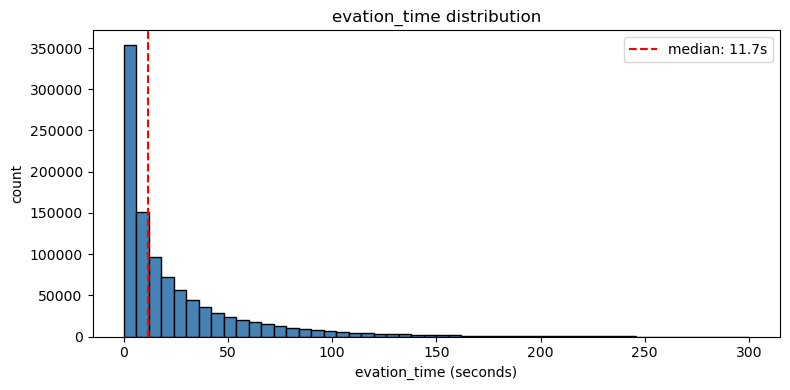

In [21]:
# Plotting histogram for evasion_time distribution

plt.figure(figsize=(8,4))
plt.hist(aircraft_df["evasion_time"], bins=50,
         color='steelblue', edgecolor='black')
plt.title('evation_time distribution')
plt.xlabel('evation_time (seconds)')
plt.ylabel('count')
plt.axvline(aircraft_df["evasion_time"].median(),
            color='red',
            linestyle="--",
            label=f"median: {aircraft_df['evasion_time'].median():.1f}s")
plt.legend()
plt.tight_layout()
plt.show()

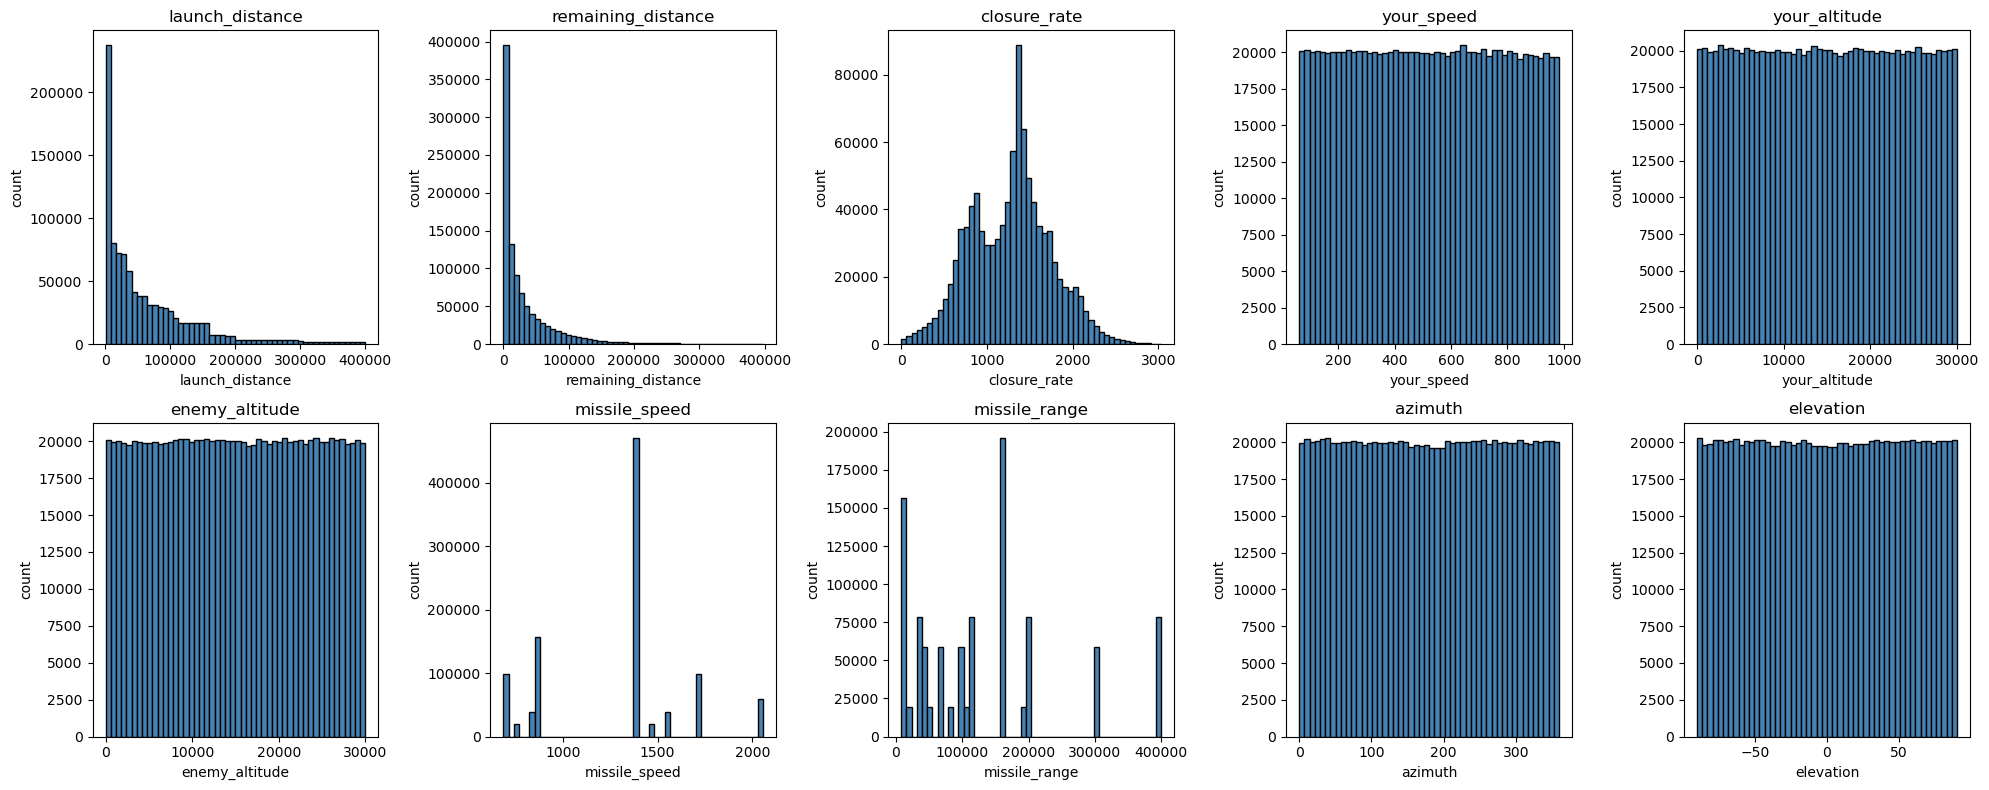

In [22]:
cols = ['launch_distance', 'remaining_distance', 'closure_rate', 
        'your_speed', 'your_altitude', 'enemy_altitude',
        'missile_speed', 'missile_range', 'azimuth', 'elevation']

fig, ax = plt.subplots(2, 5, figsize=(20, 8))
ax = ax.flatten()

for i, col in enumerate(cols):
    ax[i].hist(aircraft_df[col],
               bins=50, color='steelblue',
               edgecolor='black')
    ax[i].set_title(col)
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("count")
    
plt.tight_layout()
plt.show()

In [23]:
# Correlational matrix
corr = aircraft_df.corr()

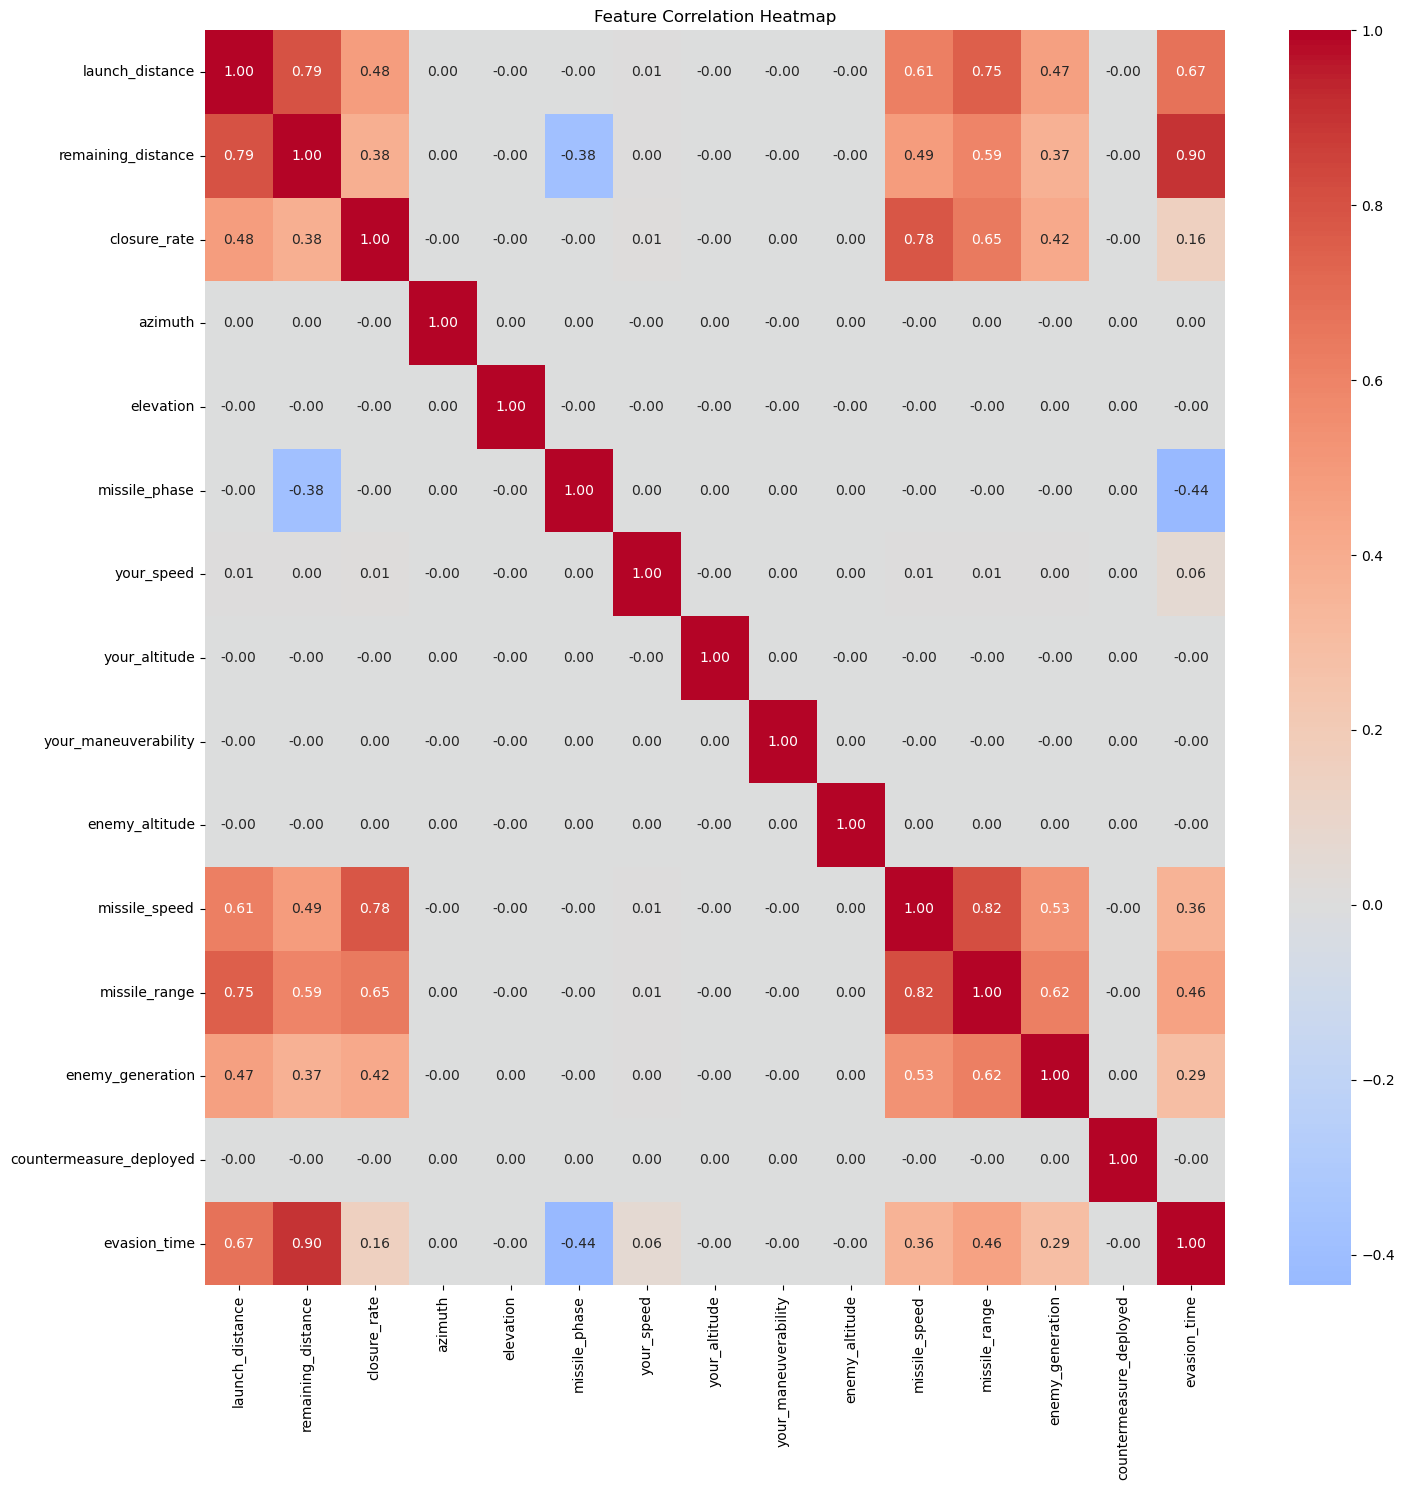

In [24]:
# Ploting the heatmap of correlational matrix

import seaborn as sns
plt.figure(figsize=(15,15))  # (width, height)
sns.heatmap(corr,
            annot=True,      # Adds numbers inside each heatmap cell
            fmt='.2f',       # Formats annotation text
            cmap='coolwarm',
            center=0)        # make 0 correlation appear as white, not skewed by data range
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show();


# coolwarm means:

# blue = negative correlation
# red = positive correlation
# white/gray = near zero

# So visually:

# strong positive → deep red
# strong negative → deep blue
# weak/no relation → neutral

### **Boxplots - evasion_time by Categorical Features**

#### **What is a Boxplot?**
A boxplot is a chart that summarizes how a numerical variable is distributed across different categories. Instead of plotting every single value, it compresses the data into 5 key numbers so you can compare groups at a glance.

#### **Why are we using it here?**
- **We want to know:** does evasion_time actually change based on missile_phase, enemy_generation, and your_maneuverability? 

- These are categorical variables (a few fixed values like 0/1/2). 

- A boxplot lets us put each category side by side and visually compare their evasion_time distributions, confirming whether the physics generator produced realistic, meaningful differences between groups.

### **How to read a Boxplot**

```markdown
o  o  o  o  o       ← outlier dots (many, clustered up here)
   o  o  o  o  o
   o  o  o  o
        |
        |           ← top whisker = "maximum" normal value
   _____|_____
  |           |     ← top of box = Q3 (75th percentile)
  |___________|     ← green line inside box = Median
  |___________|     ← bottom of box = Q1 (25th percentile)
        |
        |           ← bottom whisker (very short or invisible) = "minimum" normal value
    o o o o         ← dots above/below = outliers
```

A boxplot summarizes a distribution using 5 numbers:

- **Bottom of box** = Q1 (25th percentile) — 25% of values are below this
- **Green line** = Median (50th percentile) — the middle value
- **Top of box** = Q3 (75th percentile) — 75% of values are below this
- **Whiskers** = extend to 1.5 × IQR beyond Q1 and Q3
- **Dots beyond whiskers** = outliers (not errors — just extreme values)

**IQR (Interquartile Range)** = Q3 - Q1. This is the spread of the middle 50% of data.

**The outlier dots are not labelled on the plot their position is determined by the IQR rule:**
- Upper fence = Q3 + (1.5 × IQR) → anything above this is plotted as a dot
- Lower fence = Q1 - (1.5 × IQR) → anything below this is plotted as a dot

**Right-skewed data** means most values are low but a few extreme high values stretch the tail upward (in a vertical plot). This is why the box sits near the bottom and outlier dots pile up above it.

#### **What we are checking here**
Whether evasion_time changes meaningfully across missile_phase, enemy_generation, and your_maneuverability.
Expected behaviour:
- missile_phase 2 (terminal) → lowest evasion_time (seeker locked on)
- enemy_generation 5 → lower evasion_time (HOBS + ECCM compress reaction time)
- your_maneuverability 2 → slightly higher evasion_time (more evasion options)

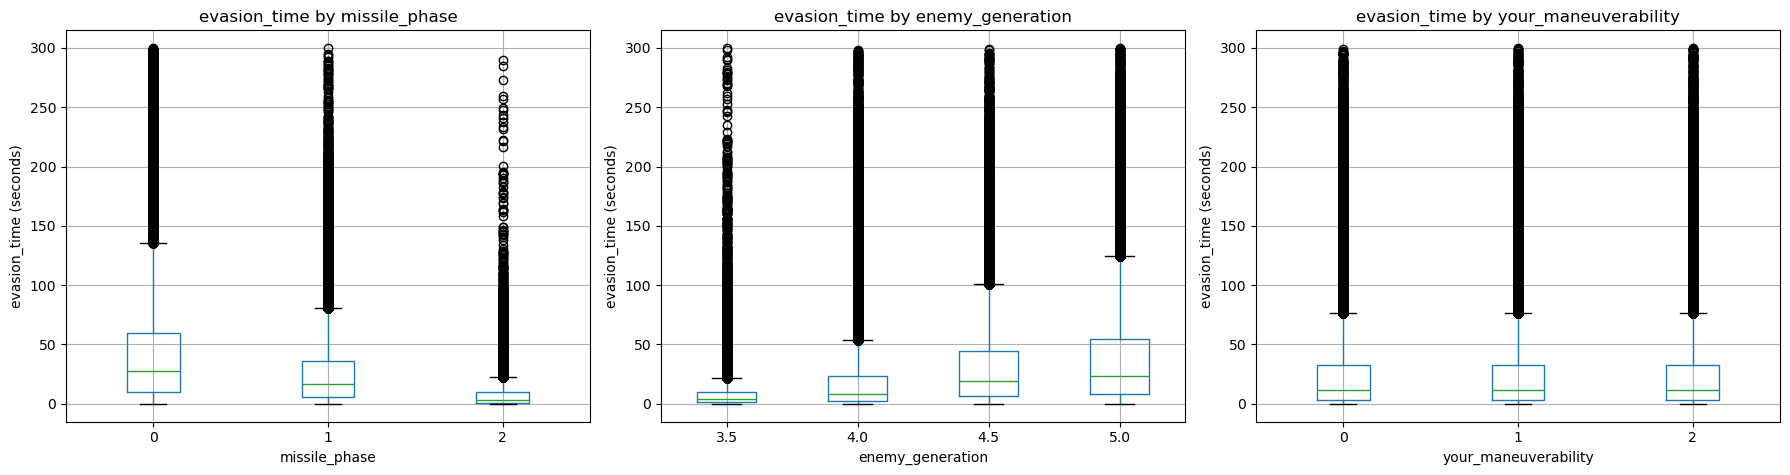

In [25]:
# Plotting Boxplot between evaison time and categorical data

fig, axis = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axis, ['missile_phase', 'enemy_generation', 'your_maneuverability']):
    aircraft_df.boxplot(column='evasion_time', by=col, ax=ax)
    ax.set_title(f'evasion_time by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('evasion_time (seconds)')
    
plt.suptitle('')
plt.tight_layout()
plt.show();

### **🧾 What we covered**
- Shape, nulls, dtypes confirmed
- Categorical distributions inspected
- Histograms for all continuous features
- Correlation heatmap
- Boxplots: evasion_time by missile_phase, enemy_generation, your_maneuverability

### **Key Findings**

- **evasion_time** is heavily right-skewed. Median ~11.7s. 50-60% of data below ~15s. Long tail to 300s cap.

- **remaining_distance** is the strongest predictor of evasion_time (r=0.90). Physically correct since distance drives arrival time.

- **missile_phase** strongly compresses evasion_time as phase increases. Validates generator logic.

- **enemy_generation** shows higher evasion_time for higher gen aircraft in the data. This is because higher gen aircraft have longer range missiles in the metadata CSV, meaning larger launch distances and more remaining_distance. This is physically correct, a missile launched from farther away genuinely takes longer to arrive. The lethality of Gen 5 threats is captured by the hit classifier, not evasion_time.
  
- **your_maneuverability** has almost no effect on evasion_time. Correct by design, it affects hit probability not arrival time.

- **azimuth and elevation** have near-zero correlation with evasion_time. Angle of attack does not change how fast the missile arrives, only how hard it is to dodge. These features belong to the hit classifier not the regressor.

- **missile_speed and missile_range** show discrete spikes. Expected, sampled from finite metadata CSV.

---

### **Evaluation Plan (decided during EDA)**

- **Metrics:** MAE, RMSE, R²

- **Residual plot:** After the model predicts, every prediction has an error (actual - predicted). A residual plot shows these errors against actual values. Random scatter around zero = good. A pattern = the model has systematic bias. We split by ETA range (0-20s vs 50s+) because the model may look great on average but be secretly bad at long-range predictions due to data imbalance.

- **Feature importance plot:** Shows which features the model relied on most overall.

- **SHAP analysis:** Goes deeper than feature importance. For each individual prediction, SHAP shows how much each feature pushed the prediction up or down. Explains why the model made a specific prediction, not just what it predicted.

- **Log transform:** evasion_time skew means the model sees far more short ETAs than long ones and gets lazy about the tail. Log transform squishes the scale so long ETAs are not so far from short ones, forcing the model to pay more attention to the tail. Formula: y = log(1 + evasion_time), invert after prediction with exp(predicted) - 1. Test this only after baseline, not before.
---

## **8. Train/Val/Test Split and Baseline Models**

### **Split Strategy**
- Train: 70%, Val: 15%, Test: 15%
- Random split, random_state=42 for reproducibility
- X = all features except evasion_time
- y = evasion_time

### **Baseline Models**
Train all three in one loop using a dictionary, compare results side by side.

**Models to compare:**
- Random Forest
- XGBoost
- LightGBM

### **Evaluation Metrics**
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R²

### **After Baseline**
- Residual plot split by ETA range (0-20s vs 50s+)
- Feature importance plot
- SHAP analysis
- If tail performance is weak, test log transform: `y = log(1 + evasion_time)`, invert after prediction with `exp(predicted) - 1`

In [26]:
# Checking number of columns before split 
len(aircraft_df.columns), len(aircraft_df)

(15, 999405)

In [27]:
# Spliting data into train, validation and test dataset

from sklearn.model_selection import train_test_split

# 1. 70% train, 30% temp data
train_df, temp_df = train_test_split(aircraft_df,
                                     test_size=0.3,
                                     random_state=42)

len(train_df), len(temp_df)

(699583, 299822)

In [28]:
# 2. Split temp data into vaidation (15%) and test data (15%)
val_df, test_df = train_test_split(temp_df,
                                   test_size=0.5,
                                   random_state=42)

len(val_df), len(test_df)

(149911, 149911)

In [29]:
# 3. resetting the indices

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [30]:
train_df.head()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,evasion_time
0,50443.89112,22221.624120,1122.861294,120.128532,47.532931,1,735.152298,437.379341,2,9529.185025,1372,200000,4.5,1,22.857655
1,30498.98615,1693.245808,776.616516,249.201565,26.371375,2,252.675394,24303.841740,1,12535.755550,857,35000,4.0,0,2.038567
2,30284.36597,16376.863000,1406.914079,77.419920,54.180381,1,273.907735,6426.486591,2,3534.095411,1372,160000,5.0,1,10.476245
3,10834.24919,5053.384643,800.303757,260.302729,50.256716,1,526.459379,22218.930960,2,29720.792310,857,40000,3.5,1,7.293055
4,44859.61521,30967.135630,1276.430275,115.784545,70.083551,0,644.963430,25476.318500,0,9197.851698,1372,160000,5.0,1,25.219033


In [31]:
val_df.head()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,evasion_time
0,51962.114030,17246.935290,1627.112137,201.645420,47.527302,2,686.538297,24538.897830,2,13860.15012,2058,100000,4.0,1,10.406276
1,45646.693470,18843.557800,2048.414414,265.734423,-81.316209,1,853.575645,11817.230490,1,15434.41563,2058,100000,4.0,1,9.659049
2,4890.207751,1859.450854,878.871669,65.052911,61.627520,1,962.284186,4813.854207,0,27995.03489,686,8000,4.0,1,2.443662
3,160243.724100,75815.934820,2328.741702,312.006966,9.028799,1,928.604542,25221.997740,0,16379.57553,1715,400000,5.0,0,33.842596
4,7994.032010,7346.046281,736.855984,42.317432,-20.183457,0,73.277393,9574.516076,0,15146.05741,686,8000,4.0,1,10.966391


In [32]:
test_df.head()

,launch_distance,remaining_distance,closure_rate,azimuth,elevation,missile_phase,your_speed,your_altitude,your_maneuverability,enemy_altitude,missile_speed,missile_range,enemy_generation,countermeasure_deployed,evasion_time
0,6602.897456,2222.933242,1563.077034,351.788312,29.861308,2,222.611891,20001.831840,1,9802.768974,1372,160000,4.0,0,1.329712
1,257685.585500,47067.152540,1716.523305,89.496557,46.496936,2,251.841906,19319.932340,2,20112.178300,1715,300000,5.0,0,20.976337
2,9546.544054,7205.115488,1300.483362,262.576731,-48.422358,0,834.106176,5336.062541,2,11794.518630,1372,160000,4.0,1,6.399089
3,72879.597330,35337.067730,1340.058376,179.326935,87.482852,1,727.345199,14536.071060,1,26378.576800,1372,110000,4.0,1,30.457116
4,380592.319800,106746.720900,1986.515397,293.199632,-23.313886,2,750.516628,23232.427270,0,2707.679719,1715,400000,5.0,0,47.479488


In [34]:
DATA_ROOT = PROJECT_ROOT / "data"
ETA_DATA_ROOT = DATA_ROOT / "eta"

In [ ]:
# 4. Saving the dataset split in parquet form

from pathlib import Path

# Making the data folder for eta data
Path(ETA_DATA_ROOT).mkdir(parents=True, exist_ok=True)

# Saving the data
print("Starting saving data...wait")

train_df.to_parquet(ETA_DATA_ROOT / "train.parquet", engine="auto",index=False)
val_df.to_parquet(ETA_DATA_ROOT / "val.parquet", engine="auto", index=False)
test_df.to_parquet(ETA_DATA_ROOT / "test.parquet", engine="auto", index=False)

print(f"Saved at {ETA_DATA_ROOT}")

Starting saving data...wait
Saved at /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data/eta


In [38]:
# Load parquet files back

print("Loading saved data...wait")

train_df = pd.read_parquet(ETA_DATA_ROOT / "train.parquet", engine="auto")
val_df = pd.read_parquet(ETA_DATA_ROOT / "val.parquet", engine="auto")
test_df = pd.read_parquet(ETA_DATA_ROOT / "test.parquet", engine="auto")

print(f"Train: {len(train_df):,} rows, {train_df.shape[1]} cols")
print(f"Val: {len(val_df):,} rows, {val_df.shape[1]} cols")
print(f"Test: {len(test_df):,} rows, {test_df.shape[1]} cols")

# Confirm index starts from 0
print(f"\nTrain index start: {train_df.index[0]}")
print(f"Val index start: {val_df.index[0]}")

print(f"Loaded dataset from {ETA_DATA_ROOT}")

Loading saved data...wait
Train: 699,583 rows, 15 cols
Val: 149,911 rows, 15 cols
Test: 149,911 rows, 15 cols

Train index start: 0
Val index start: 0
Loaded dataset from /mnt/d/Eakem/Learning ML and DS/Project_ATAS/ATAS_Project/data/eta


In [40]:
# Function to split data into X and y

def get_X_and_y(df):
    X = df.drop(columns=["evasion_time"])
    y = df["evasion_time"]
    
    return X, y

# Splitting target and features
X_train, y_train = get_X_and_y(train_df)
X_val, y_val = get_X_and_y(val_df)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}")

X_train: (699583, 14)
y_train: (699583,)
X_val: (149911, 14)
y_val: (149911,)
